In [86]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns
import colorcet as cc
import sklearn

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.models.mil_species_detector import MILSpeciesDetector

preds_path = pathlib.Path("/its/home/kag25/experiments/v3/bayesian_species_detectors/predictions")
model_path = pathlib.Path("/its/home/kag25/models/v3/bayesian_species_detectors/")

scope = "SO_UK"
model_name = "wanted-pencil"

model = MILSpeciesDetector.load_from_checkpoint(model_path / f"{model_name}_{scope}.ckpt")
species_names = dict(zip(range(len(model.target_names)), model.target_names))
df = pd.read_parquet(preds_path / "test.parquet" / f"{model_name}-{scope}.parquet").reset_index()
df["species_name"] = df.species_i.map(species_names)
df = df.rename(columns=dict(t="timestep"))
df.head()

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

,dataloader_idx,file_i,sample_i,timestep,species_i,y_t_prob,mu_a,sigma_sq_a,attn_w,species_name
0,2,4,0,0,0,0.006671,-5.021415,0.018413,0.012631,Aythya collaris_Ring-necked Duck
1,2,4,0,0,1,0.000010,-11.593601,0.046807,0.014201,Falco columbarius_Merlin
2,2,4,0,0,2,0.000026,-10.692964,0.064739,0.023981,Cuculus canorus_Common Cuckoo
3,2,4,0,0,3,0.005646,-5.216372,0.044724,0.078505,Erithacus rubecula_European Robin
4,2,4,0,0,4,0.000003,-12.811995,0.043241,0.002051,Strix aluco_Tawny Owl


In [99]:
labels = pd.read_parquet(f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/{scope}/test/labels.parquet")
labels = labels.melt(var_name="species_name", value_name="y", ignore_index=False)
labels

,species_name,y
file_i,,
4,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
11,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
12,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
14,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
19,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
...,...,...
1981,Vanellus vanellus_Northern Lapwing,0
1988,Vanellus vanellus_Northern Lapwing,0
1989,Vanellus vanellus_Northern Lapwing,0


In [99]:
labels = pd.read_parquet(f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/{scope}/test/labels.parquet")
labels = labels.melt(var_name="species_name", value_name="y", ignore_index=False)
labels

,species_name,y
file_i,,
4,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
11,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
12,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
14,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
19,Acrocephalus scirpaceus_Eurasian Reed Warbler,0
...,...,...
1981,Vanellus vanellus_Northern Lapwing,0
1988,Vanellus vanellus_Northern Lapwing,0
1989,Vanellus vanellus_Northern Lapwing,0


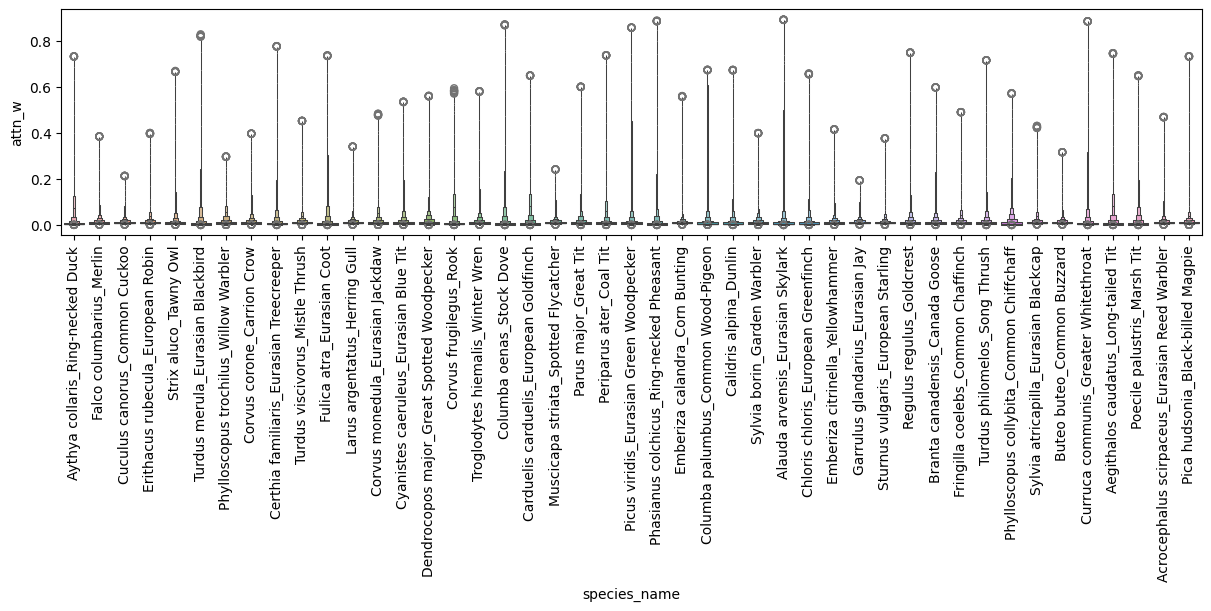

In [2]:
fig = plt.figure(figsize=(12, 6), constrained_layout=True)
sns.boxenplot(data=df, x="species_name", y="attn_w", hue="species_name")
plt.gca().tick_params("x", rotation=90)
plt.show()

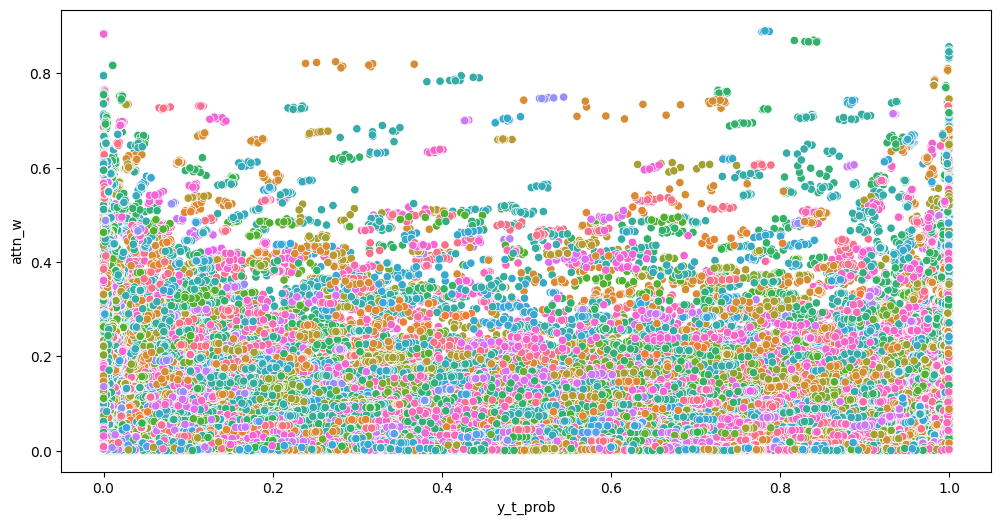

In [22]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="y_t_prob", y="attn_w", hue="species_name", legend=False)
plt.show()

In [133]:
seq_len = df["timestep"].max()
max_attn_entropy = np.log(seq_len)
seq_len, max_attn_entropy

def seq_entropy(attn_w):
    return -np.sum(attn_w * np.log(attn_w))

attn_entropy_df = (
    df.groupby(["file_i", "dataloader_idx", "sample_i", "species_name"])
    ["attn_w"]
    .apply(seq_entropy)
    .reset_index()
    .rename(columns=dict(attn_w="attn_entropy"))
    .groupby(["file_i", "dataloader_idx", "species_name"])
    ["attn_entropy"]
    .mean()
    .reset_index()
)
attn_entropy_df = attn_entropy_df.merge(labels, how="left", on=["file_i", "species_name"])
attn_entropy_df["dkl"] = max_entropy - attn_entropy_df["attn_entropy"]
attn_entropy_df

,file_i,dataloader_idx,species_name,attn_entropy,y,dkl
0,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,4.039676,0,0.291057
1,4,2,Aegithalos caudatus_Long-tailed Tit,2.816191,0,1.514542
2,4,2,Alauda arvensis_Eurasian Skylark,3.717256,0,0.613477
3,4,2,Aythya collaris_Ring-necked Duck,3.573489,0,0.757244
4,4,2,Branta canadensis_Canada Goose,3.900776,0,0.429958
...,...,...,...,...,...,...
18220,2017,2,Sylvia borin_Garden Warbler,3.756540,0,0.574194
18221,2017,2,Troglodytes hiemalis_Winter Wren,3.302450,0,1.028283
18222,2017,2,Turdus merula_Eurasian Blackbird,2.958956,1,1.371778
18223,2017,2,Turdus philomelos_Song Thrush,3.066669,1,1.264064


In [134]:
train_labels = pd.read_parquet(f"/its/home/kag25/data/soundscape_vae_embeddings/{model_name}/{scope}/train/labels.parquet")
train_labels = train_labels.melt(var_name="species_name", value_name="y", ignore_index=False)
order = train_labels[train_labels.y == 1].groupby("species_name")["y"].count().sort_values(ascending=False).reset_index().species_name.tolist()

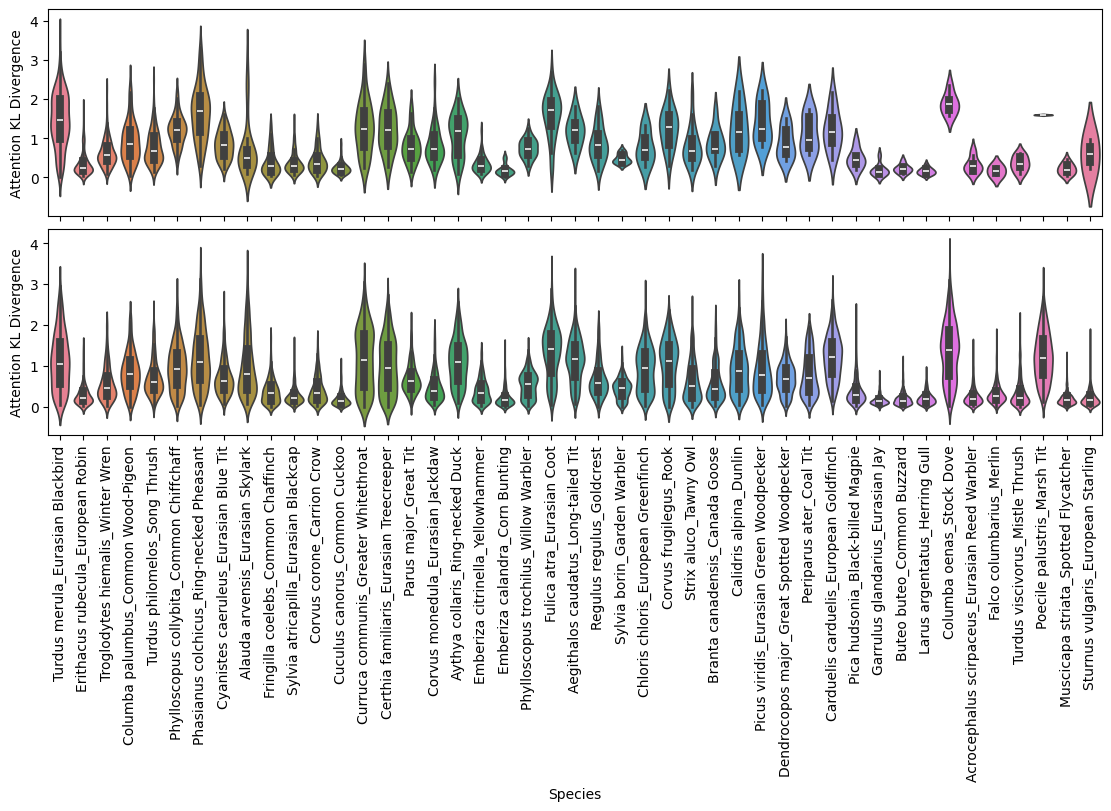

In [136]:
species = df1.species_name.unique()
order = [species_name for species_name in order if species_name in species] 

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(11, 8), sharex=True, constrained_layout=True)
sns.violinplot(data=attn_entropy_df[attn_entropy_df.y == 1], y="dkl", x="species_name", hue="species_name", order=order, hue_order=order, legend=False, ax=ax1)
ax1.set_ylabel("Attention KL Divergence")
ax1.set_xlabel("")

sns.violinplot(data=attn_entropy_df[attn_entropy_df.y == 0], y="dkl", x="species_name", hue="species_name", order=order, hue_order=order, legend=False, ax=ax2)
ax2.set_ylabel("Attention KL Divergence")
ax2.tick_params(axis='x', labelrotation=90)
ax2.set_xlabel("Species")
plt.show()


In [62]:
attn_w_df = df.groupby(["file_i", "dataloader_idx", "species_name", "timestep"])[["attn_w", "y_t_prob"]].mean().reset_index()
attn_w_df

,file_i,dataloader_idx,species_name,timestep,attn_w,y_t_prob
0,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,0,0.125195,3.000261e-03
1,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,1,0.017393,6.505552e-04
2,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,2,0.008214,2.667262e-04
3,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,3,0.013163,6.686463e-05
4,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,4,0.004707,7.819305e-07
...,...,...,...,...,...,...
1403320,2017,2,Turdus viscivorus_Mistle Thrush,72,0.014885,2.182147e-05
1403321,2017,2,Turdus viscivorus_Mistle Thrush,73,0.012818,3.090955e-05
1403322,2017,2,Turdus viscivorus_Mistle Thrush,74,0.003769,3.809178e-05
1403323,2017,2,Turdus viscivorus_Mistle Thrush,75,0.016330,7.615748e-07


In [52]:
shift_entropy_df = pd.read_parquet(root / "dump" / "frame_shift_entropy.parquet").reset_index()
shift_entropy_df = shift_entropy_df[shift_entropy_df.dataloader_idx == 2]

In [63]:
df1 = attn_w_df.merge(shift_entropy_df, how="left", on=["file_i", "dataloader_idx", "timestep"])
df1

,file_i,dataloader_idx,species_name,timestep,attn_w,y_t_prob,h
0,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,0,0.125195,3.000261e-03,6.634794
1,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,1,0.017393,6.505552e-04,6.634794
2,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,2,0.008214,2.667262e-04,6.634794
3,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,3,0.013163,6.686463e-05,6.634794
4,4,2,Acrocephalus scirpaceus_Eurasian Reed Warbler,4,0.004707,7.819305e-07,6.634794
...,...,...,...,...,...,...,...
1403320,2017,2,Turdus viscivorus_Mistle Thrush,72,0.014885,2.182147e-05,6.557518
1403321,2017,2,Turdus viscivorus_Mistle Thrush,73,0.012818,3.090955e-05,6.557518
1403322,2017,2,Turdus viscivorus_Mistle Thrush,74,0.003769,3.809178e-05,6.557518
1403323,2017,2,Turdus viscivorus_Mistle Thrush,75,0.016330,7.615748e-07,6.557518


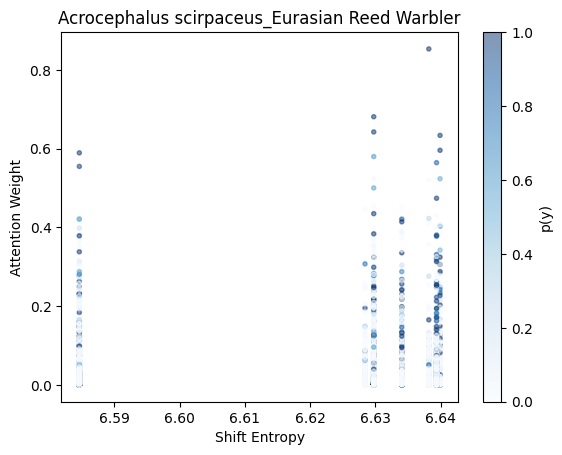

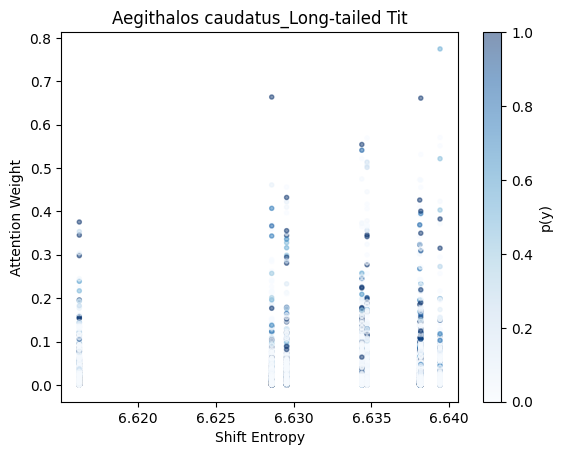

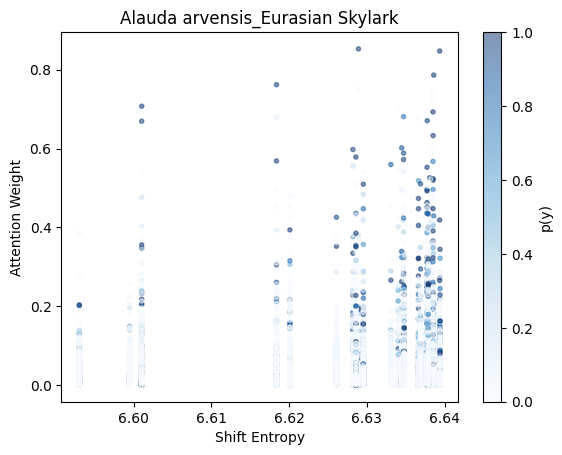

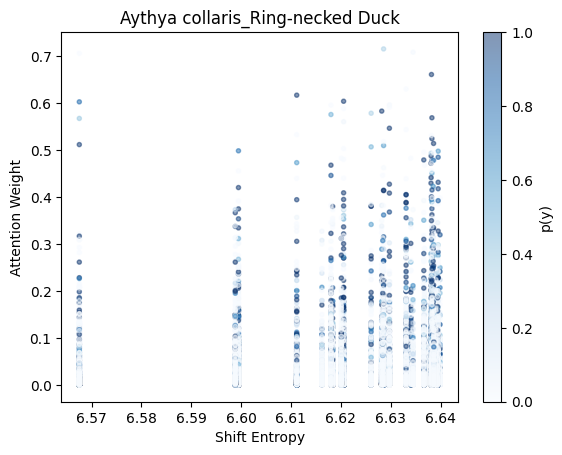

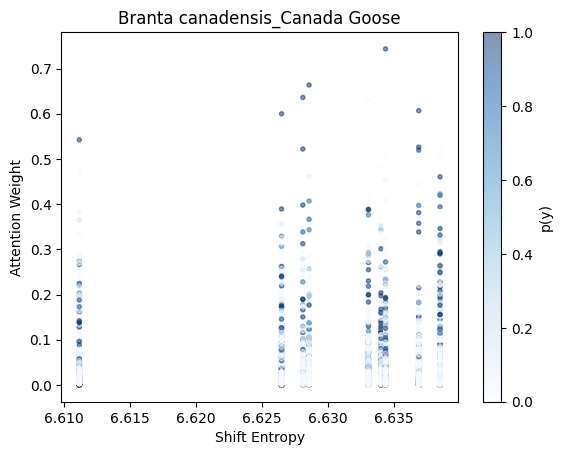

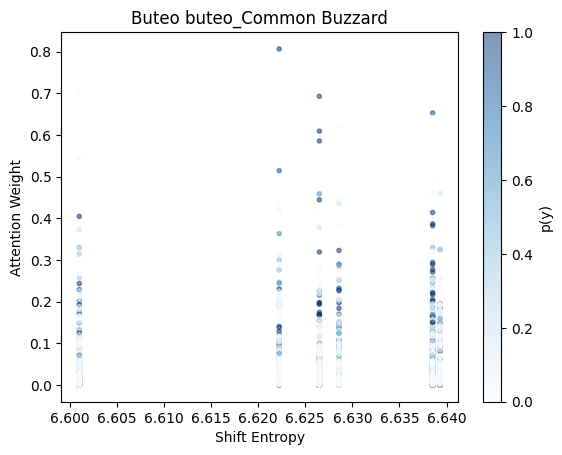

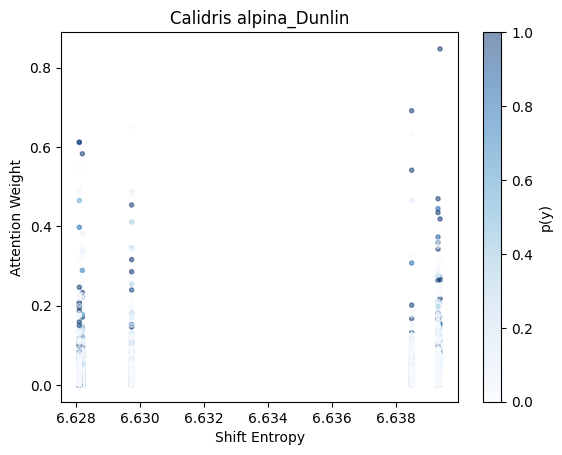

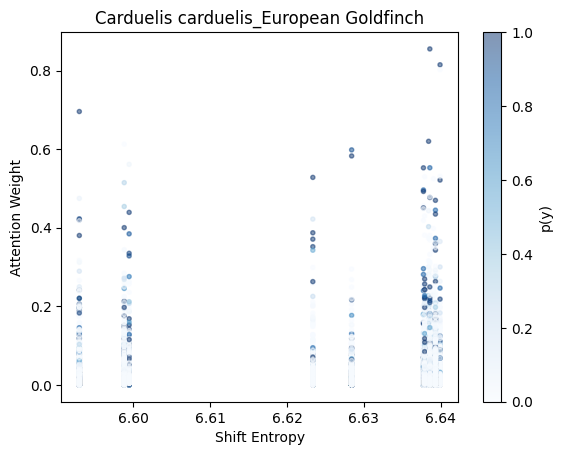

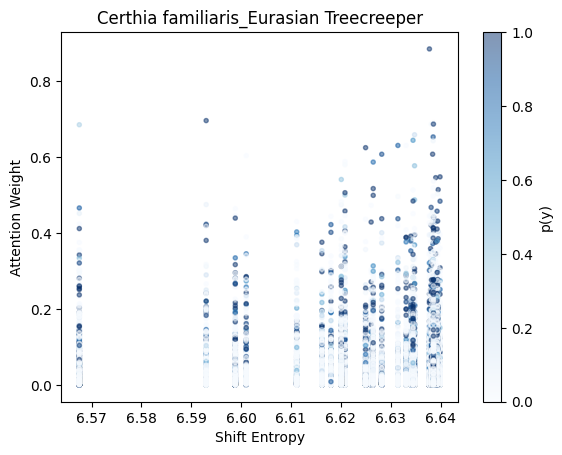

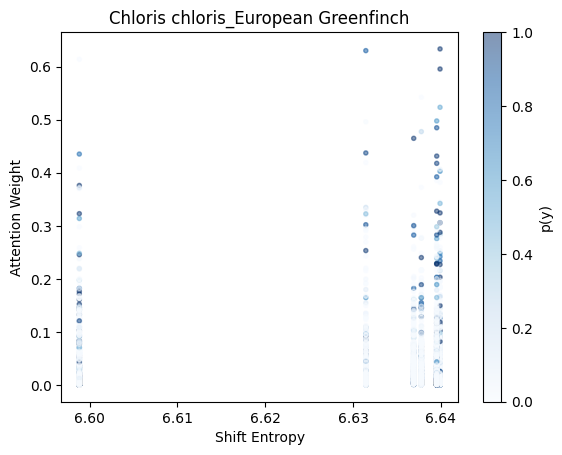

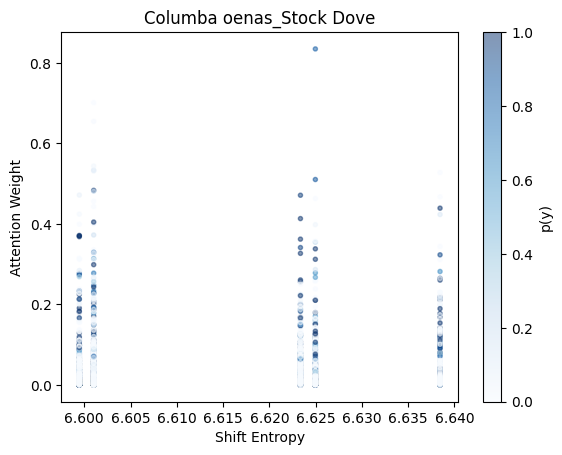

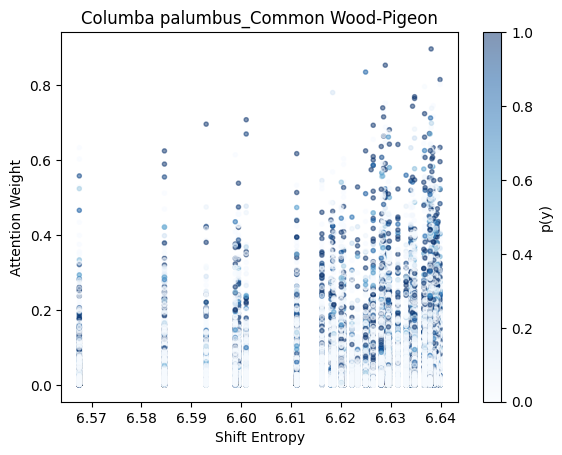

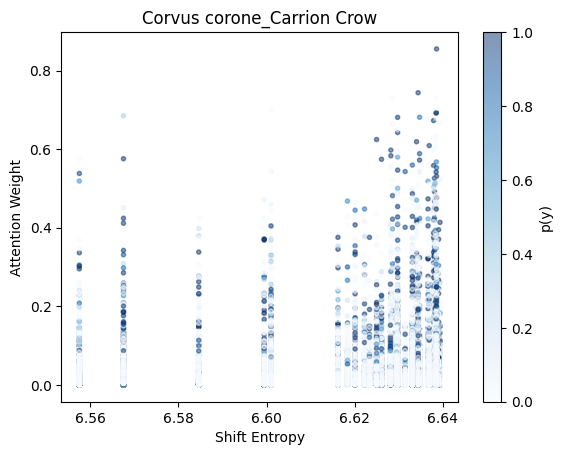

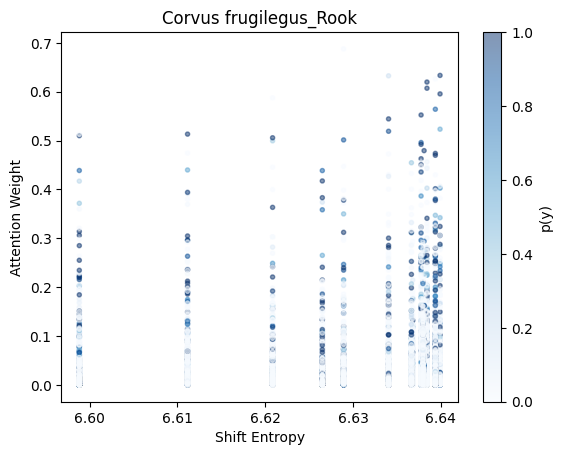

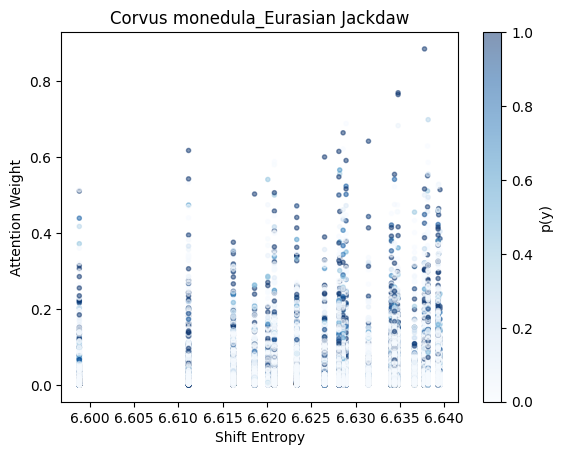

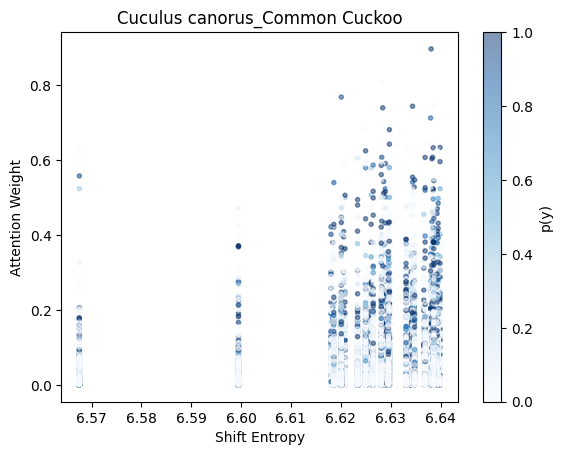

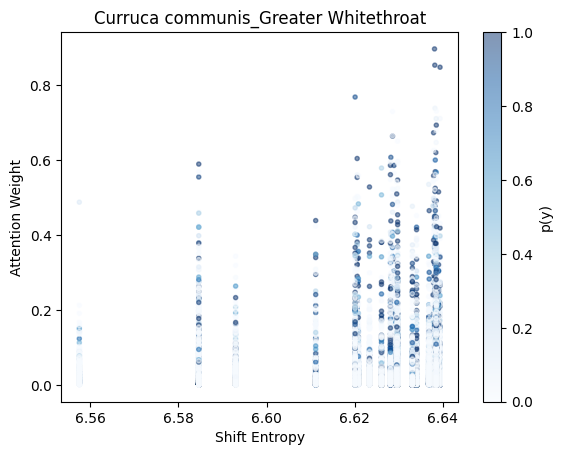

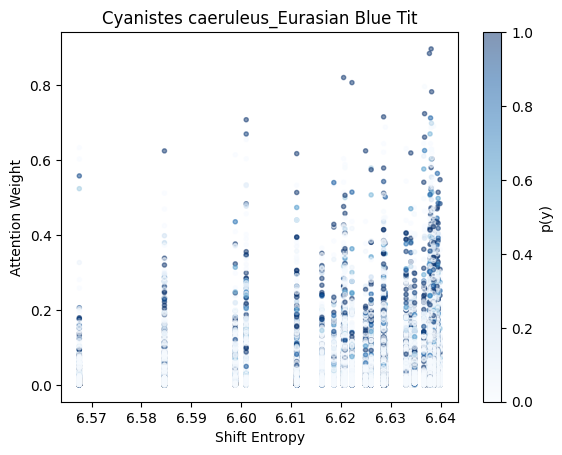

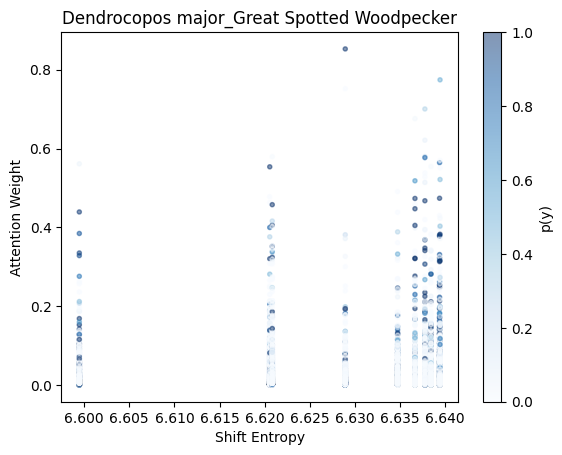

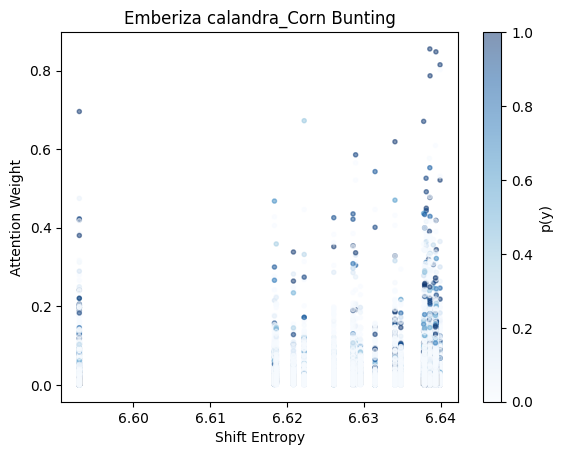

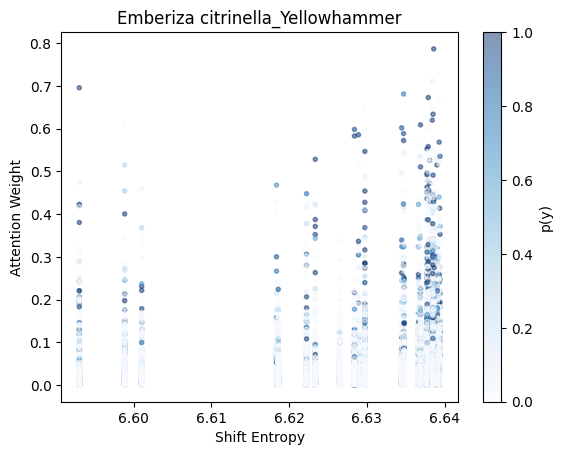

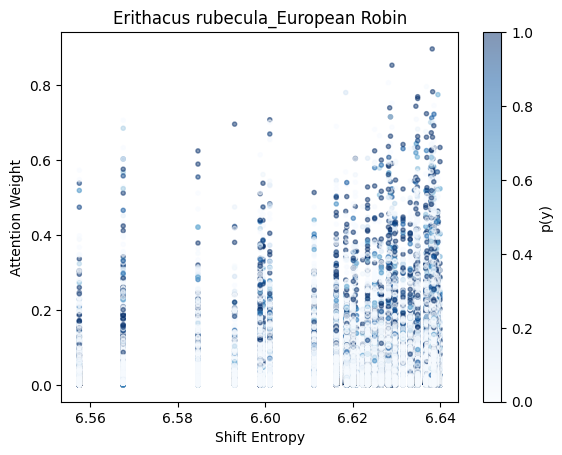

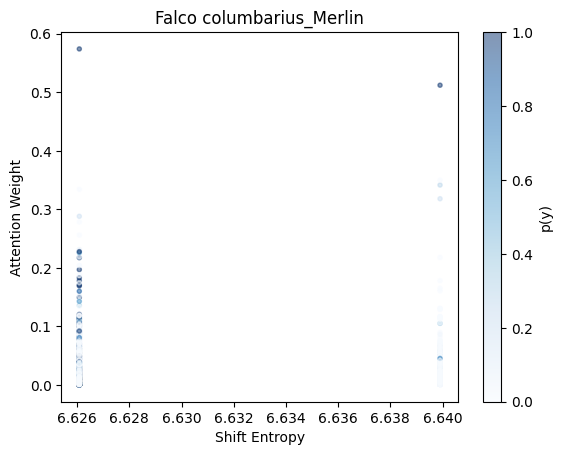

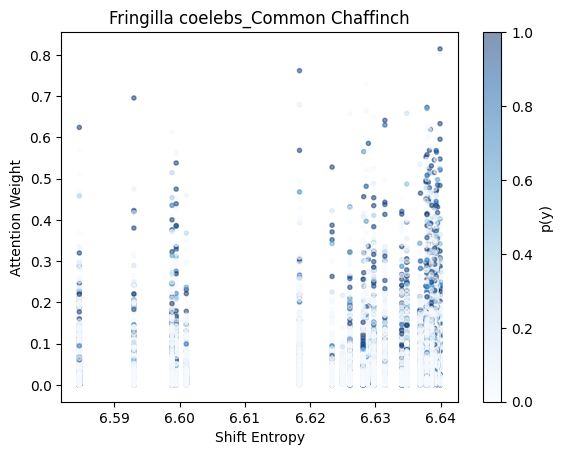

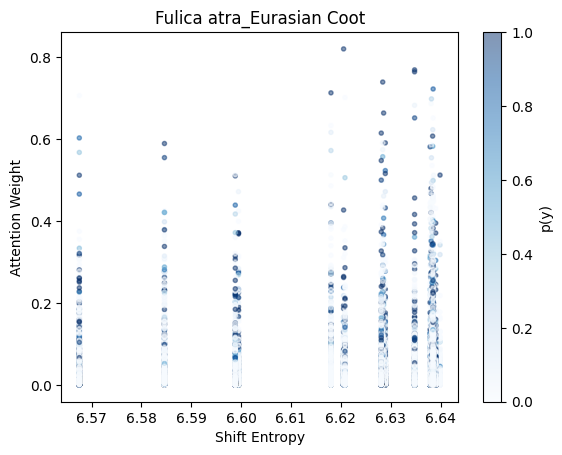

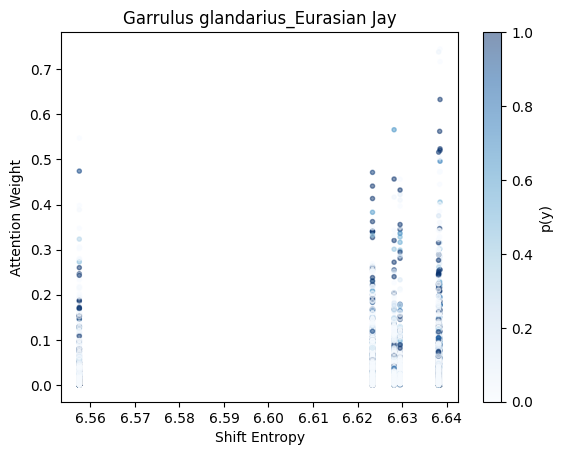

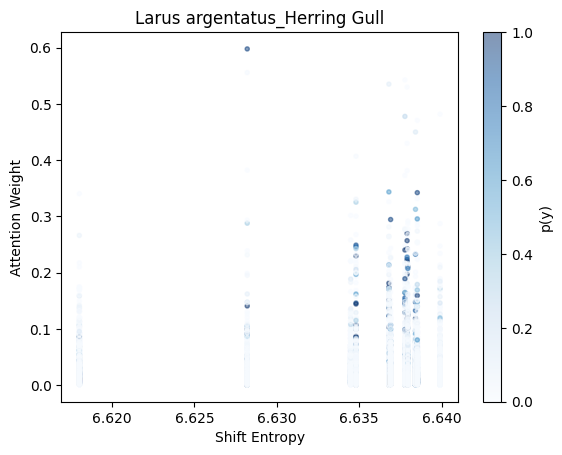

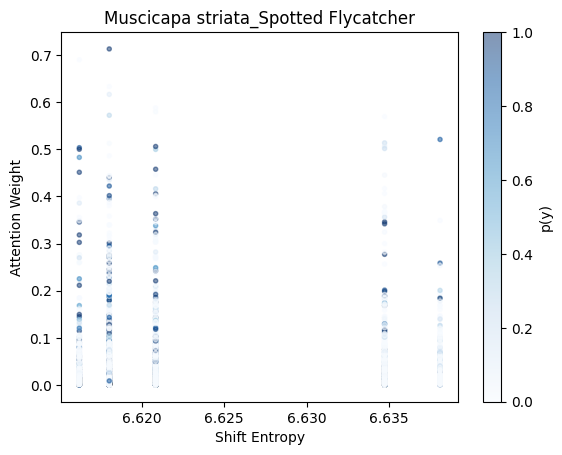

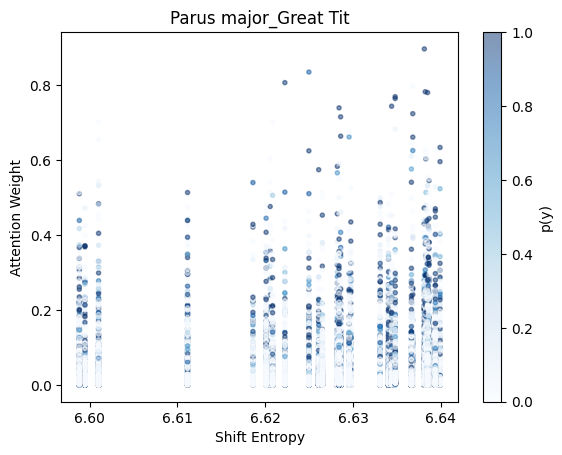

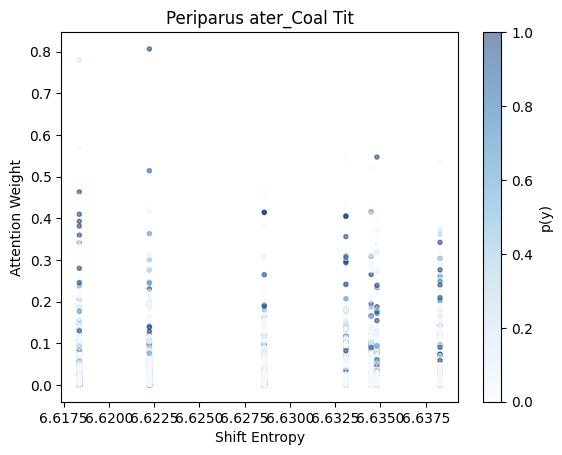

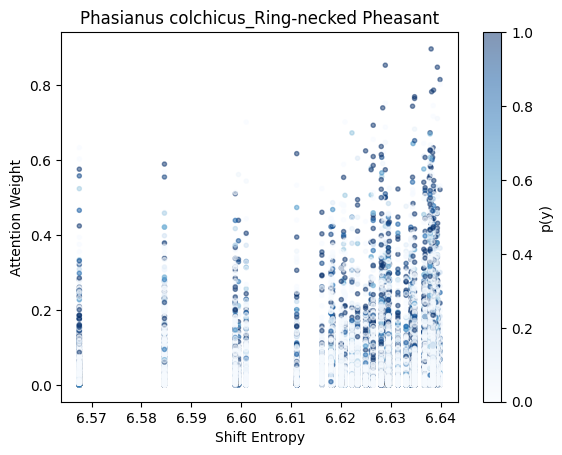

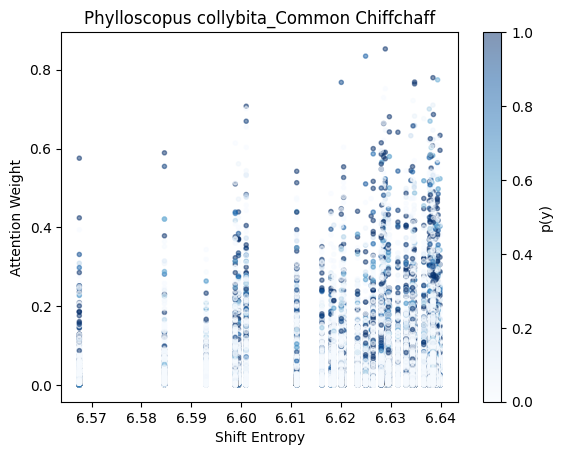

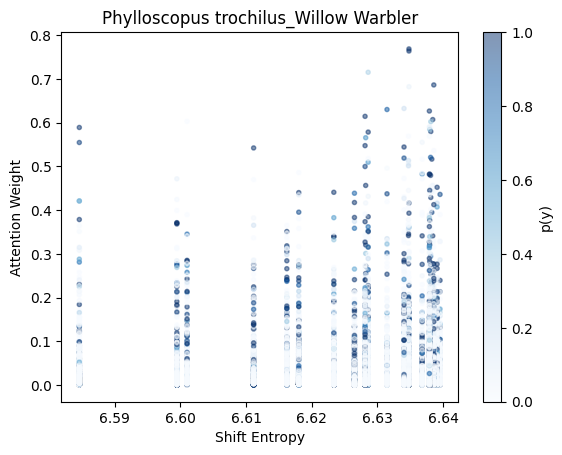

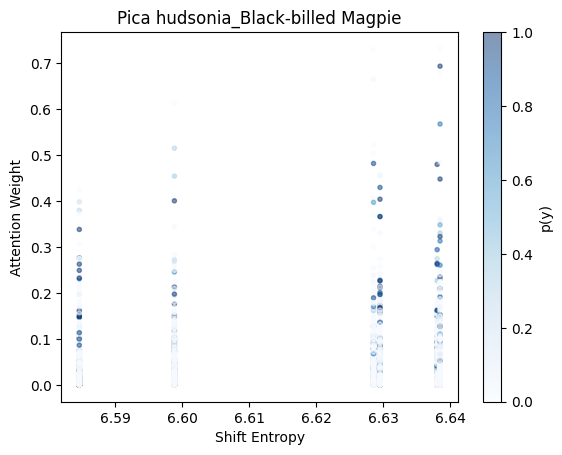

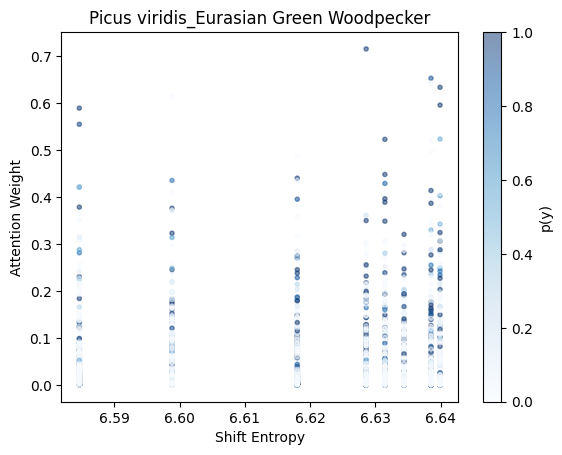

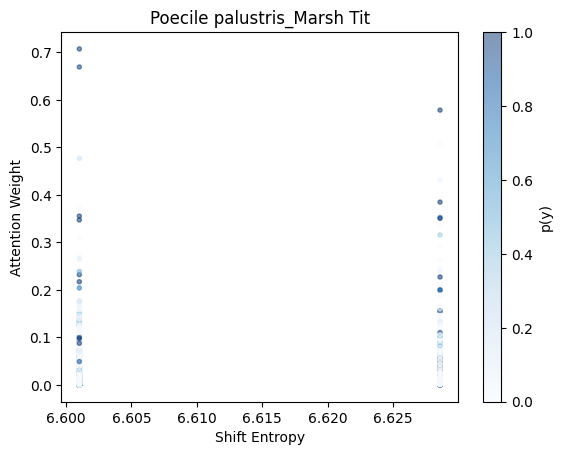

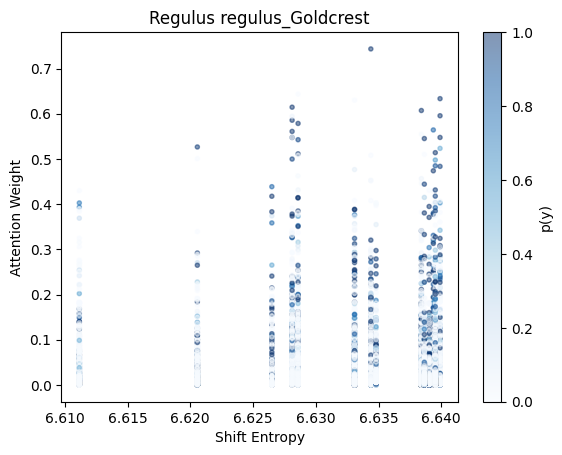

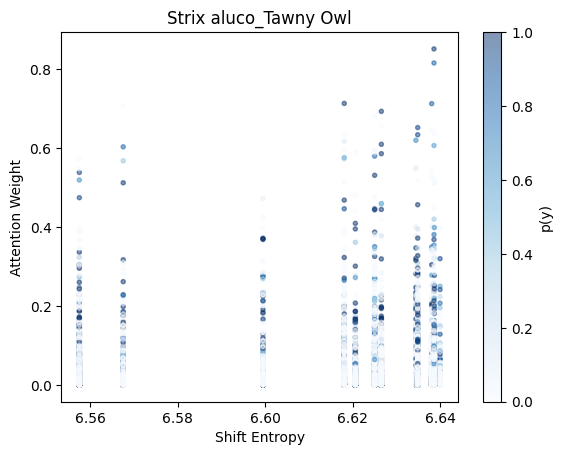

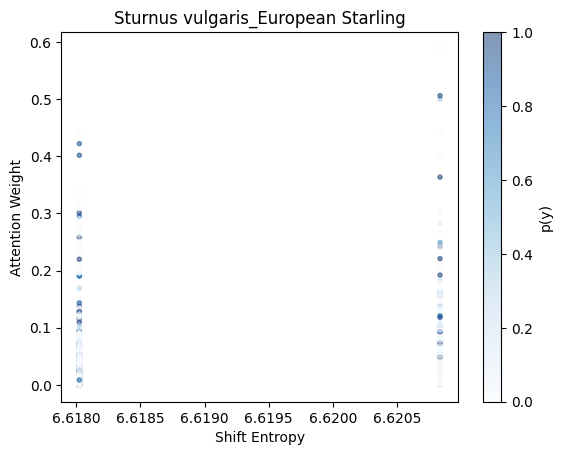

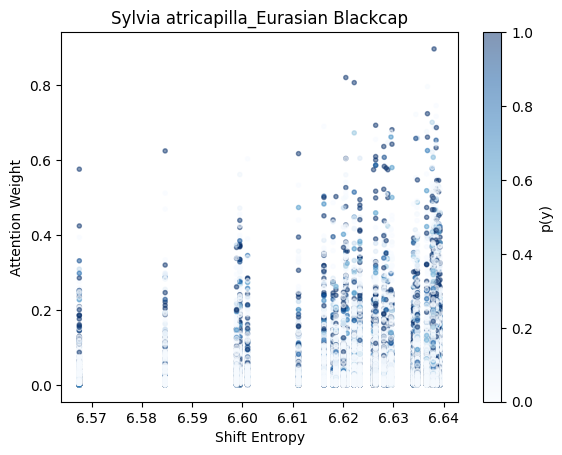

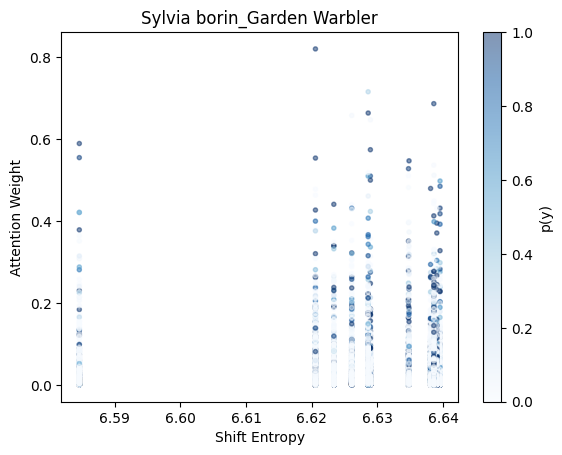

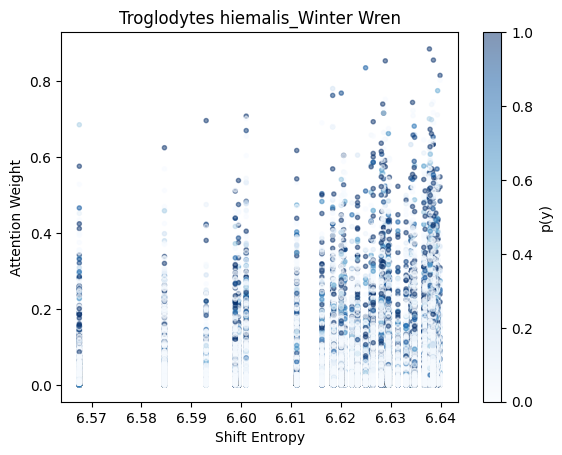

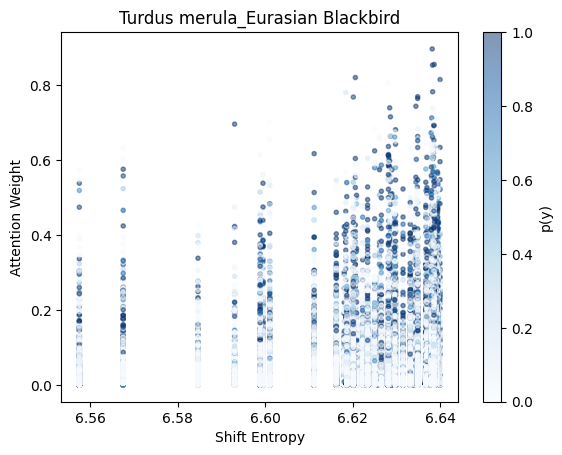

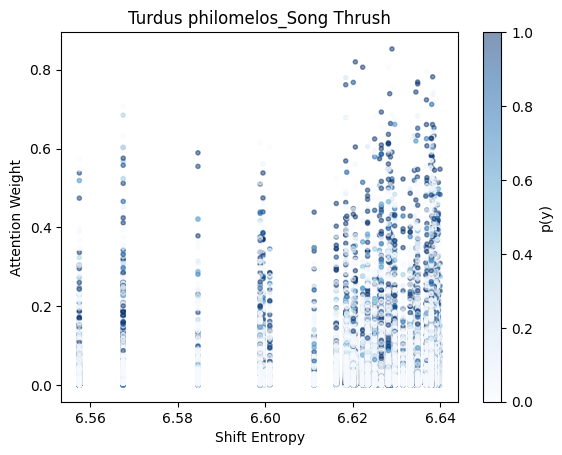

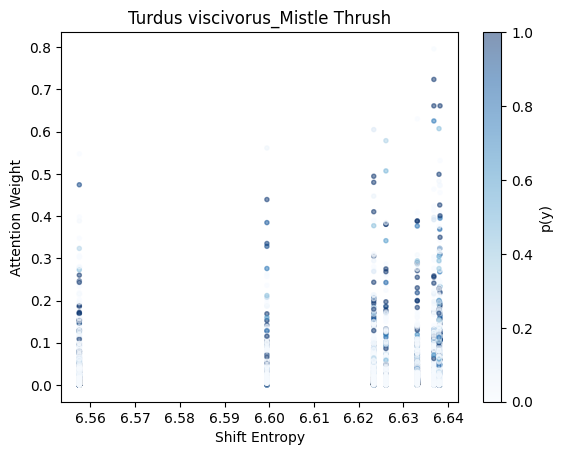

In [93]:
for species_name in df1.species_name.unique():
    slab = labels[(labels.species_name == species_name) & (labels.y == 1)]
    sdf = df1[df1.file_i.isin(slab.index)]
    fig, ax = plt.subplots()
    sc = ax.scatter(sdf["h"], sdf["attn_w"], c=sdf["y_t_prob"], vmin=0, vmax=1, cmap="Blues", alpha=0.5, marker=".")
    ax.set_xlabel("Shift Entropy")
    ax.set_ylabel("Attention Weight")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("p(y)")
    ax.set_title(species_name)
    plt.show()